# Experiment 4 — Hard vs Soft (Gaussian) Matching

**Goal:** Compare nearest-neighbour (hard) ICP against Gaussian-weighted (soft) ICP with sigma annealing on the `clustered` cloud style.

For each matcher we show:
1. Per-iteration convergence curves for a single run (residual, rotation error, translation error).
2. Multi-seed boxplots of final errors.

In [ ]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from icp import ICP, GaussianMatcher, SigmaAnnealingCallback
from synthetic import SyntheticExperiment
from utils import rotation_angle_error

plt.style.use('seaborn-v0_8-whitegrid')

N_SEEDS    = 30
MAX_ITER   = 400
TOL        = 1e-10
GEN_KWARGS = dict(n=2000, noise_std=3.0, t_scale=8.0, style='clustered')

# Gaussian matcher / annealing hyperparameters
SIGMA_INIT  = 25.0
SIGMA_FINAL = 1.0
K_NEIGHBORS = 20

BOX_STYLE = dict(
    patch_artist=True,
    whiskerprops=dict(color='#333333', linewidth=1.5),
    capprops=dict(color='#333333', linewidth=1.5),
    medianprops=dict(color='gold', linewidth=2),
    flierprops=dict(marker='o', markersize=5, markerfacecolor='#555555',
                    markeredgewidth=0, alpha=0.6, linestyle='none'),
)

def make_soft_icp():
    """Create a fresh Gaussian ICP with an annealing callback."""
    matcher = GaussianMatcher(sigma=SIGMA_INIT, k=K_NEIGHBORS)
    annealer = SigmaAnnealingCallback(matcher, SIGMA_INIT, SIGMA_FINAL, MAX_ITER)
    return ICP(matcher=matcher, max_iter=MAX_ITER, tol=TOL, callbacks=[annealer])

## 1. Single-run convergence

Both matchers run on the same experiment (seed=42, clustered).  The per-iteration curves show how fast each one descends and whether they reach the correct solution.

In [ ]:
exp = SyntheticExperiment.generate(**GEN_KWARGS, seed=42)

# Hard ICP (nearest-neighbour)
result_hard = ICP(max_iter=MAX_ITER, tol=TOL).fit(exp.P, exp.Q)

# Soft ICP (Gaussian with annealing)
result_soft = make_soft_icp().fit(exp.P, exp.Q)

print(f'Hard ICP — converged: {result_hard.converged}, iters: {result_hard.n_iterations}')
print(f'Soft ICP — converged: {result_soft.converged}, iters: {result_soft.n_iterations}')

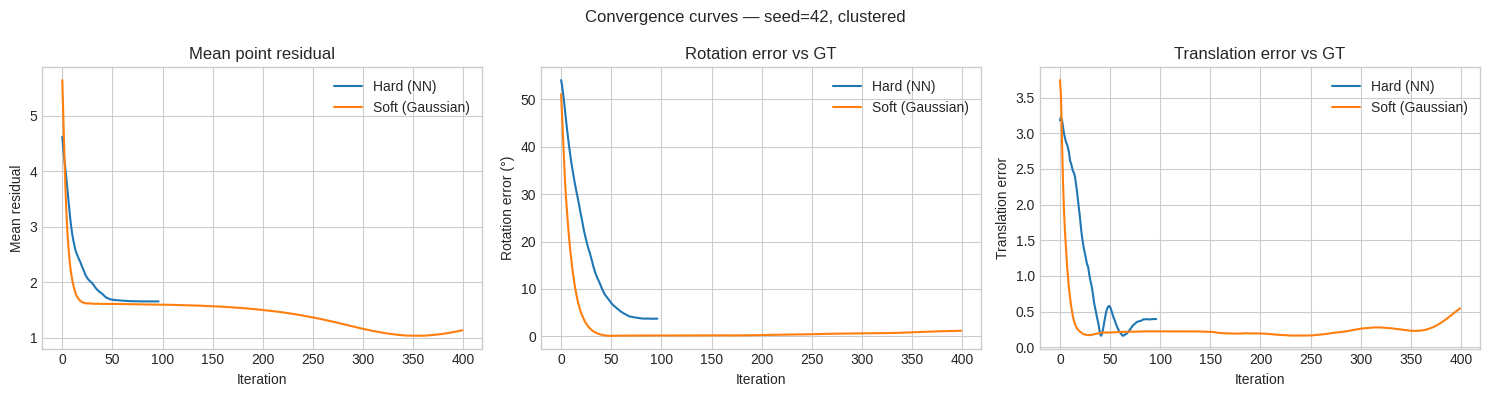

In [3]:
def trajectory_errors(result, exp):
    """Per-iteration rotation and translation error relative to ground truth."""
    rot = [rotation_angle_error(exp.T_gt.R, T.R) for T in result.transform_history]
    t   = [np.linalg.norm(exp.T_gt.t - T.t)       for T in result.transform_history]
    return rot, t

rot_hard, t_hard = trajectory_errors(result_hard, exp)
rot_soft, t_soft = trajectory_errors(result_soft, exp)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(result_hard.mean_residuals, label='Hard (NN)',       color='tab:blue')
axes[0].plot(result_soft.mean_residuals, label='Soft (Gaussian)', color='tab:orange')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Mean residual')
axes[0].set_title('Mean point residual')
axes[0].legend()

axes[1].plot(rot_hard, label='Hard (NN)',       color='tab:blue')
axes[1].plot(rot_soft, label='Soft (Gaussian)', color='tab:orange')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Rotation error (°)')
axes[1].set_title('Rotation error vs GT')
axes[1].legend()

axes[2].plot(t_hard, label='Hard (NN)',       color='tab:blue')
axes[2].plot(t_soft, label='Soft (Gaussian)', color='tab:orange')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Translation error')
axes[2].set_title('Translation error vs GT')
axes[2].legend()

plt.suptitle('Convergence curves — seed=42, clustered')
plt.tight_layout()
plt.savefig('../results/experiment_4_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Multi-seed evaluation

Run both matchers on 30 random seeds and compare the distribution of final errors.

In [ ]:
def run_seeds(matcher_factory, n_seeds=N_SEEDS, desc=''):
    """Run ICP on n_seeds experiments; return arrays of final rot_err, t_err, max_residual."""
    rot_errs, t_errs, max_res = [], [], []
    for seed in tqdm(range(n_seeds), desc=desc):
        exp_s    = SyntheticExperiment.generate(**GEN_KWARGS, seed=seed)
        result_s = matcher_factory().fit(exp_s.P, exp_s.Q)
        T        = result_s.transformation
        Q_pred   = T.apply(exp_s.P)
        residuals = np.linalg.norm(Q_pred.points - exp_s.Q.points, axis=1)
        rot_errs.append(rotation_angle_error(exp_s.T_gt.R, T.R))
        t_errs.append(np.linalg.norm(exp_s.T_gt.t - T.t))
        max_res.append(float(residuals.max()))
    return {
        'rot_err':      np.array(rot_errs),
        't_err':        np.array(t_errs),
        'max_residual': np.array(max_res),
    }

metrics_hard = run_seeds(
    lambda: ICP(max_iter=MAX_ITER, tol=TOL),
    desc='Hard (NN)',
)
metrics_soft = run_seeds(
    make_soft_icp,
    desc='Soft (Gaussian)',
)

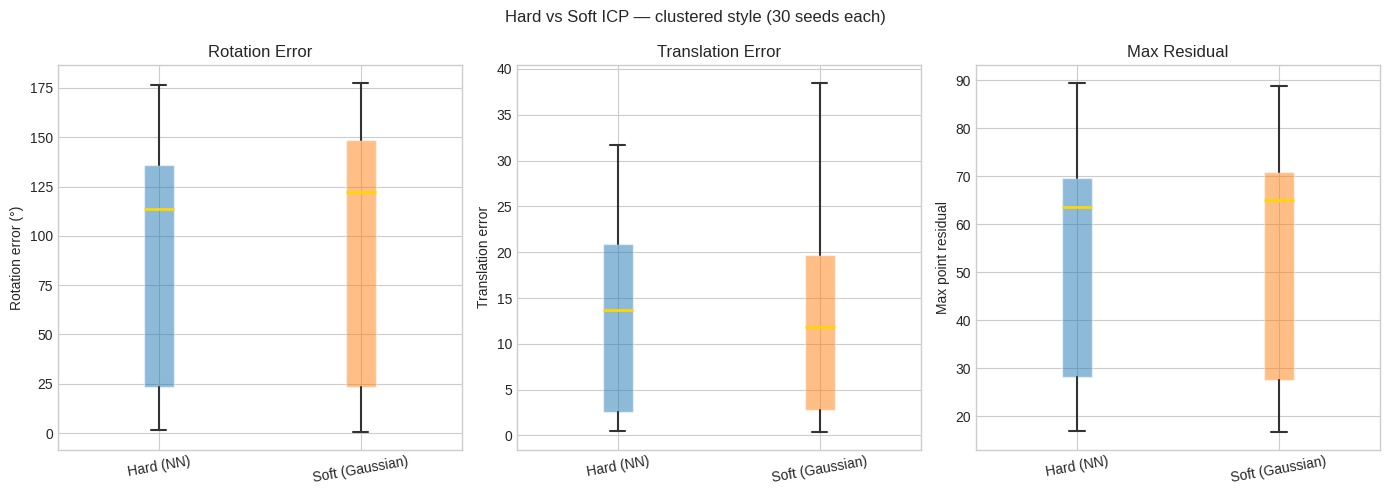

In [7]:
METRICS = [
    ('rot_err',      'Rotation error (°)',  'Rotation Error'),
    ('t_err',        'Translation error',   'Translation Error'),
    ('max_residual', 'Max point residual',  'Max Residual'),
]
LABELS = ['Hard (NN)', 'Soft (Gaussian)']
COLORS = ['tab:blue',  'tab:orange']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (key, ylabel, title) in zip(axes, METRICS):
    data = [metrics_hard[key], metrics_soft[key]]
    bp   = ax.boxplot(data, vert=True, tick_labels=LABELS, **BOX_STYLE)
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=10)

fig.suptitle(f'Hard vs Soft ICP — clustered style ({N_SEEDS} seeds each)')
plt.tight_layout()
plt.savefig('../results/experiment_4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()